# Calculating the surface area of tissue compartments and mapping it back to the adata object

In [1]:
import scanpy as sc

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")


In [2]:
#compartment segmentation paths
from pathlib import Path

ctrl = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\output-XETG00160__0093234__ctrl__20260211__140710\Compartment_segmentations")
D3IMQ = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\output-XETG00160__0093234__D3IMQ__20260211__140710\Compartment_Segmentations")
D7IMQ = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\output-XETG00160__0093234__D7IMQ__20260211__140710\Compartment segmentations")
D10IMQ = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\output-XETG00160__0093234__D10imq__20260211__140710\Compartment segmentations")

In [3]:
import json
from pathlib import Path
from shapely.geometry import shape as shapely_shape
from shapely.ops import unary_union

XENIUM_PIXEL_SIZE_UM = 0.2125  # micrometers per pixel

from shapely.ops import unary_union

def read_shape(geojson_path):
    with open(geojson_path) as f:
        geojson = json.load(f)
    
    geom_type = geojson.get('type', '').lower()
    
    if geom_type == 'featurecollection':
        # union all features into one geometry
        geometries = [shapely_shape(feature['geometry']) for feature in geojson['features']]
        return unary_union(geometries)
    elif geom_type == 'feature':
        return shapely_shape(geojson['geometry'])
    else:
        # raw geometry dict (Polygon, MultiPolygon, etc.)
        return shapely_shape(geojson)

def surface_area_um2(shape):
    return shape.area * (XENIUM_PIXEL_SIZE_UM ** 2)

condition_shapes = {}  # {e.g. 'Ctrl_F1': {'ventral_dermis': 100, ...}}

for file_glob, condition_name in [(ctrl, 'Ctrl'), (D3IMQ, 'D3IMQ'), (D7IMQ, 'D7IMQ'), (D10IMQ, 'D10IMQ')]:
    
    for file in file_glob.glob("*.geojson"):
        stem = file.stem  # e.g. 'ventral_dermis_F1'
        
        # parse region name
        if 'artilage' in stem:
            shape_key = 'cartilage'
        elif 'entral' in stem:
            shape_key = 'ventral_epidermis' if 'pidermis' in stem else 'ventral_dermis'
        elif 'orsal' in stem:
            shape_key = 'dorsal_epidermis' if 'pidermis' in stem else 'dorsal_dermis'
        else:
            print(f"Warning: unrecognised file {file.name}, skipping")
            continue
        
        if condition_name != 'D3IMQ':
            rep_number = stem[-2:]  # e.g. 'F1'
            key = f"{condition_name}_{rep_number}"  # e.g. 'Ctrl_F1'
        
        else:
            rep_number = stem[3:5]
            key = f"{condition_name}_{rep_number}"
        
        geom = read_shape(file)
        area = surface_area_um2(geom)
        
        if key not in condition_shapes:
            condition_shapes[key] = {}
        condition_shapes[key][shape_key] = area


In [51]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

FEMALE_COLOR = '#8B0000'   # dark red
MALE_COLOR   = '#002147'   # oxford blue
CONDITION_ORDER = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

def plot_surface_area_by_condition(condition_shapes, compartment, ax=None):
    """
    condition_shapes : dict like {'Ctrl_F1': {'ventral_dermis': 1234, ...}, ...}
    compartment      : str, e.g. 'ventral_dermis'
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    female_data = {c: [] for c in CONDITION_ORDER}
    male_data   = {c: [] for c in CONDITION_ORDER}

    for key, shapes in condition_shapes.items():
        if compartment not in shapes:
            continue
        # key is like 'Ctrl_F1' or 'D3IMQ_M2'
        parts = key.split('_')
        condition = parts[0] if len(parts) == 3 else '_'.join(parts[:-1])
        rep = parts[-1]  # e.g. 'F1', 'M2'

        if condition not in CONDITION_ORDER:
            continue

        if rep.startswith('F'):
            female_data[condition].append(shapes[compartment])
        elif rep.startswith('M'):
            male_data[condition].append(shapes[compartment])

    positions_f = np.arange(len(CONDITION_ORDER)) - 0.2
    positions_m = np.arange(len(CONDITION_ORDER)) + 0.2

    def styled_boxplot(data_list, positions, color):
        bp = ax.boxplot(
            data_list,
            positions=positions,
            widths=0.3,
            patch_artist=True,
            manage_ticks=False,
            boxprops    =dict(facecolor=color + '44', color=color, linewidth=1.5),
            medianprops =dict(color=color, linewidth=2.5),
            whiskerprops=dict(color=color, linewidth=1.5),
            capprops    =dict(color=color, linewidth=1.5),
            flierprops  =dict(marker='o', markerfacecolor=color, markeredgecolor=color,
                              markersize=5, alpha=0.6),
        )
        # overlay individual points
        for i, vals in enumerate(data_list):
            jitter = np.random.uniform(-0.06, 0.06, size=len(vals))
            ax.scatter(np.full(len(vals), positions[i]) + jitter, vals,
                       color=color, s=30, zorder=3, alpha=0.8)
        return bp

    styled_boxplot([female_data[c] for c in CONDITION_ORDER], positions_f, FEMALE_COLOR)
    styled_boxplot([male_data[c]   for c in CONDITION_ORDER], positions_m, MALE_COLOR)

    ax.set_xticks(np.arange(len(CONDITION_ORDER)))
    ax.set_xticklabels(CONDITION_ORDER)
    ax.set_ylabel('Surface area (µm²)')
    ax.set_title(compartment.replace('_', ' ').title())
    ax.spines[['top', 'right']].set_visible(False)

    legend_handles = [
        mpatches.Patch(facecolor=FEMALE_COLOR, edgecolor=FEMALE_COLOR, label='Female'),
        mpatches.Patch(facecolor=MALE_COLOR,   edgecolor=MALE_COLOR,   label='Male'),
    ]
    ax.legend(handles=legend_handles, frameon=False)

    plt.tight_layout()
    return ax

In [9]:
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

FEMALE_COLOR = '#8B0000'   # dark red
MALE_COLOR   = '#002147'   # oxford blue
CONDITION_ORDER = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

def plot_surface_area_by_condition(condition_shapes, compartment, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    female_data = {c: [] for c in CONDITION_ORDER}
    male_data   = {c: [] for c in CONDITION_ORDER}

    for key, shapes in condition_shapes.items():
        if compartment not in shapes:
            continue
        parts = key.split('_')
        condition = parts[0] if len(parts) == 3 else '_'.join(parts[:-1])
        rep = parts[-1]
        if condition not in CONDITION_ORDER:
            continue
        if rep.startswith('F'):
            female_data[condition].append(shapes[compartment])
        elif rep.startswith('M'):
            male_data[condition].append(shapes[compartment])

    positions_f = np.arange(len(CONDITION_ORDER)) - 0.2
    positions_m = np.arange(len(CONDITION_ORDER)) + 0.2

    def styled_boxplot(data_list, positions, color):
        bp = ax.boxplot(
            data_list,
            positions=positions,
            widths=0.3,
            patch_artist=True,
            manage_ticks=False,
            showfliers = False,
            boxprops    =dict(facecolor=color, alpha =0.7, color=color, linewidth=1.5),
            medianprops =dict(color=color, linewidth=2.5),
            whiskerprops=dict(color=color, linewidth=1.5),
            capprops    =dict(color=color, linewidth=1.5),
            flierprops  =dict(marker='o', markerfacecolor=color, markeredgecolor=color,
                              markersize=5, alpha=0.6),
        )
        for i, vals in enumerate(data_list):
            jitter = np.random.uniform(-0.06, 0.06, size=len(vals))
            ax.scatter(np.full(len(vals), positions[i]) + jitter, vals,
                       color=color, s=30, zorder=3, alpha=0.8)
        return bp

    styled_boxplot([female_data[c] for c in CONDITION_ORDER], positions_f, FEMALE_COLOR)
    styled_boxplot([male_data[c]   for c in CONDITION_ORDER], positions_m, MALE_COLOR)

    ax.set_xticks(np.arange(len(CONDITION_ORDER)))
    ax.set_xticklabels(CONDITION_ORDER)
    ax.set_ylabel('Surface area (µm²)')
    ax.set_title(compartment.replace('_', ' ').title())
    ax.spines[['top', 'right']].set_visible(False)

    # --- significance braces ---
    def format_pvalue(p):
        if p < 0.001: suffix = '***'
        elif p < 0.01:  suffix = '**'
        elif p < 0.05:  suffix = '*'
        else:           suffix = 'ns'
        return f'p = {p:.3f} {suffix}'

    def draw_brace(ax, x_f, x_m, y_top, p):
        """Draw a bracket between two box positions with a p-value label."""
        label = format_pvalue(p)
        tick_h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.015
        ax.plot([x_f, x_f, x_m, x_m],
                [y_top, y_top + tick_h, y_top + tick_h, y_top],
                lw=1.2, color='black')
        ax.text((x_f + x_m) / 2, y_top + tick_h * 1.3, label,
                ha='center', va='bottom', fontsize=8,
                color='black' if p < 0.05 else '#888888')

    # work out brace heights — sit just above the tallest whisker/outlier per condition
    y_min, y_max = ax.get_ylim()
    span = y_max - y_min

    for i, condition in enumerate(CONDITION_ORDER):
        f_vals = female_data[condition]
        m_vals = male_data[condition]
        if len(f_vals) < 2 or len(m_vals) < 2:
            continue  # need at least 2 samples per group for a t-test

        _, p = stats.ttest_ind(f_vals, m_vals)

        # brace sits above the higher of the two groups' maxima
        group_top = max(max(f_vals), max(m_vals))
        brace_y = group_top + span * 0.04

        draw_brace(ax, positions_f[i], positions_m[i], brace_y, p)

    # expand y-axis headroom so braces aren't clipped
    ax.set_ylim(y_min, y_max + span * 0.18)

    legend_handles = [
        mpatches.Patch(facecolor=FEMALE_COLOR, edgecolor=FEMALE_COLOR, label='Female'),
        mpatches.Patch(facecolor=MALE_COLOR,   edgecolor=MALE_COLOR,   label='Male'),
    ]
    ax.legend(handles=legend_handles, frameon=False)
    plt.tight_layout()
    return ax

In [26]:
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

FEMALE_COLOR = '#8B0000'
MALE_COLOR   = '#002147'
CONDITION_ORDER = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

def plot_surface_area_by_condition(condition_shapes, compartment, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    female_data = {c: [] for c in CONDITION_ORDER}
    male_data   = {c: [] for c in CONDITION_ORDER}

    for key, shapes in condition_shapes.items():
        if compartment not in shapes:
            continue
        parts = key.split('_')
        condition = parts[0] if len(parts) == 3 else '_'.join(parts[:-1])
        rep = parts[-1]
        if condition not in CONDITION_ORDER:
            continue
        if rep.startswith('F'):
            female_data[condition].append(shapes[compartment] / 1e6)
        elif rep.startswith('M'):
            male_data[condition].append(shapes[compartment] / 1e6)

    positions_f = np.arange(len(CONDITION_ORDER)) - 0.2
    positions_m = np.arange(len(CONDITION_ORDER)) + 0.2

    def styled_boxplot(data_list, positions, color):
        bp = ax.boxplot(
            data_list,
            positions=positions,
            widths=0.3,
            patch_artist=True,
            manage_ticks=False,
            showfliers=False,
            boxprops    =dict(facecolor=color, alpha=0.7, color="#000204", linewidth=1.5),
            medianprops =dict(color='black', linewidth=2.5),
            whiskerprops=dict(color=color, linewidth=1.5),
            capprops    =dict(color=color, linewidth=1.5),
            flierprops  =dict(marker='o', markerfacecolor=color, markeredgecolor=color,
                              markersize=5, alpha=0.6),
        )
        for i, vals in enumerate(data_list):
            jitter = np.random.uniform(-0.06, 0.06, size=len(vals))
            ax.scatter(np.full(len(vals), positions[i]) + jitter, vals,
                       color=color, s=30, zorder=3, alpha=0.8)
        return bp

    styled_boxplot([female_data[c] for c in CONDITION_ORDER], positions_f, FEMALE_COLOR)
    styled_boxplot([male_data[c]   for c in CONDITION_ORDER], positions_m, MALE_COLOR)

    ax.set_xticks(np.arange(len(CONDITION_ORDER)))
    ax.set_xticklabels(CONDITION_ORDER, fontsize = 13)
    ax.set_ylabel('Surface area (mm²)', fontsize = 15)
    ax.set_title(f'{compartment.replace('_', ' ').title()} surface area')
    #ax.spines[['top', 'right']].set_visible(False)

    def format_pvalue(p):
        if p < 0.001: suffix = '***'
        elif p < 0.01:  suffix = '**'
        elif p < 0.05:  suffix = '*'
        else:           suffix = 'ns'
        return f'p = {p:.3f} {suffix}'

    def draw_brace(ax, x_f, x_m, y_top, p):
        label = format_pvalue(p)
        tick_h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.015
        ax.plot([x_f, x_f, x_m, x_m],
                [y_top, y_top + tick_h, y_top + tick_h, y_top],
                lw=1.2, color='black')
        ax.text((x_f + x_m) / 2, y_top + tick_h * 1.3, label,
                ha='center', va='bottom', fontsize=8,
                color='black' if p < 0.05 else '#888888')

    y_min, y_max = ax.get_ylim()
    span = y_max - y_min

    for i, condition in enumerate(CONDITION_ORDER):
        f_vals = female_data[condition]
        m_vals = male_data[condition]
        if len(f_vals) < 2 or len(m_vals) < 2:
            continue

        _, p = stats.ttest_ind(f_vals, m_vals)

        group_top = max(max(f_vals), max(m_vals))
        brace_y = group_top + span * 0.04

        draw_brace(ax, positions_f[i], positions_m[i], brace_y, p)

    ax.set_ylim(y_min, y_max + span * 0.18)

    legend_handles = [
        mpatches.Patch(facecolor=FEMALE_COLOR, edgecolor=FEMALE_COLOR, label='Female'),
        mpatches.Patch(facecolor=MALE_COLOR,   edgecolor=MALE_COLOR,   label='Male'),
    ]
    ax.legend(handles=legend_handles, frameon=True, edgecolor = 'black')
    plt.tight_layout()
    plt.savefig(fr"C:\Users\dbuxton\OneDrive\Desktop\biochem\Year 4\Thesis\results figures or slides\Final assembly\inflam_kinetics_figures\{title}", dpi = 500)
    return ax

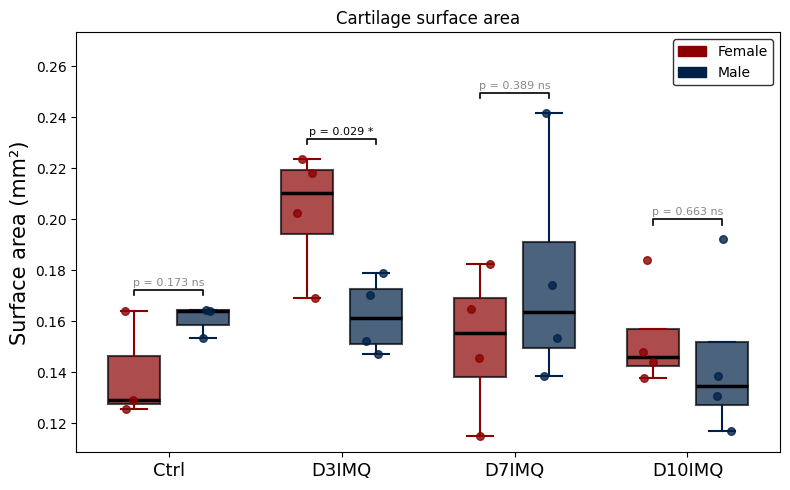

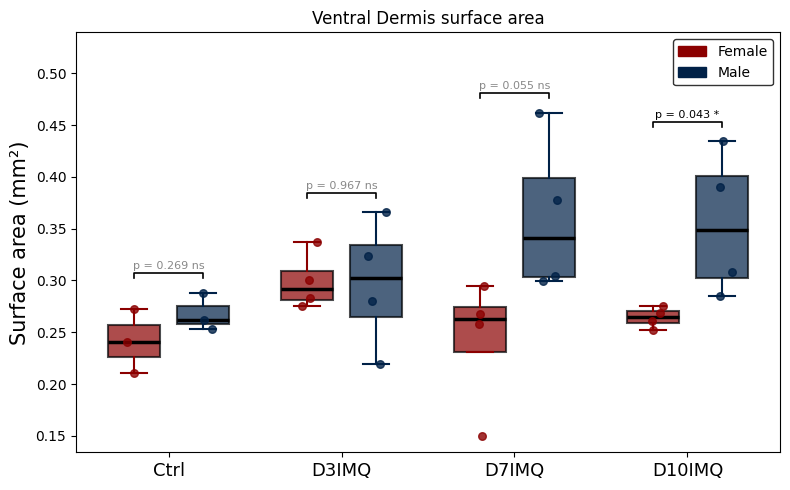

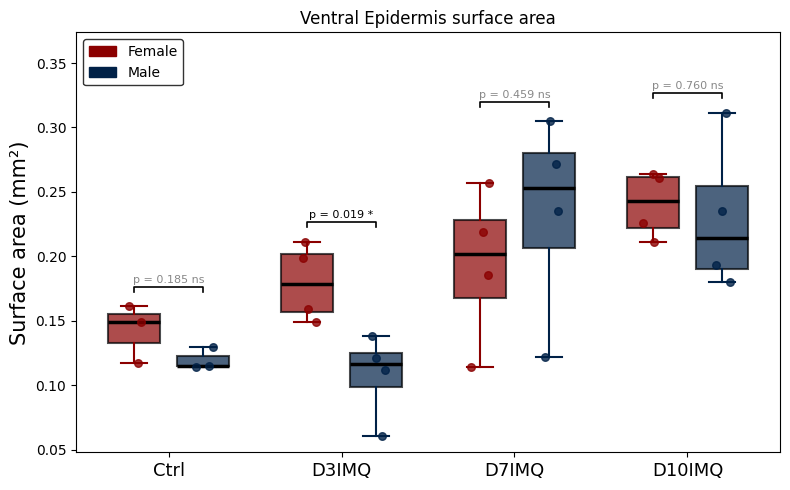

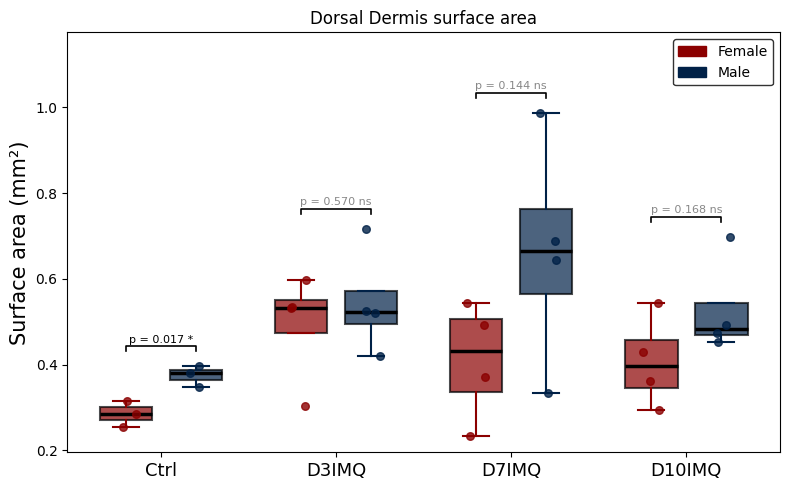

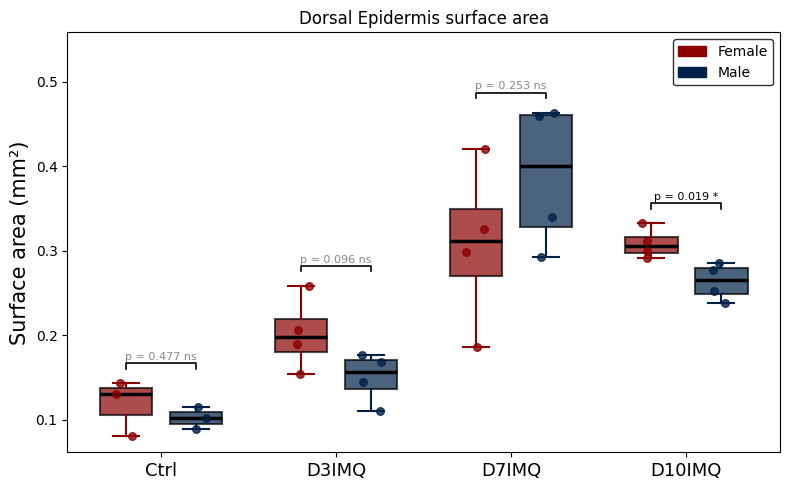

In [27]:
for compartment in ['cartilage', 'ventral_dermis', 'ventral_epidermis', 'dorsal_dermis', 'dorsal_epidermis']:
    title = f'{compartment} surface area'
    plot_surface_area_by_condition(condition_shapes, compartment, title = title)

In [62]:
# add to anndata
adata.uns['region_surface_areas_um2'] = condition_shapes

In [63]:
adata.write_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")

# side quest, adding back in unassigned cells

In [ ]:
adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")

raw_path = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\raw_adatas")

raw_adatas = {}

for file in raw_path.glob("*h5ad"):
    raw_adatas[file.stem.removesuffix("raw_adata")] = sc.read_h5ad(file)
    #e.g Ctrl_F1 = adata --> contains 6000 cells, while adata[adata.obs['batch_key'] == 'Ctrl_F1'] may only have ~4000 cells (key point is fewer cells)
    #both the raw adatas and the big adata have .obs['cell_id'], and while overall in the big adata there may be replicates, when grouping by batch_key, there won't be replicates.
    #so I want to add the cell_ids not present in the big_adata for a given replicate into the big adata, and for any columns that aren't in the raw adata, just add 'unassigned' --> specifically for celltype_assignments, where you might have to add it as a new category, since the data is categorical

In [6]:
import pandas as pd
import scanpy as sc
from pathlib import Path

# 1. Load your master AnnData (if not already loaded)
adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
raw_path = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\raw_adatas")

# Ensure celltype_assignments is categorical and has 'unassigned' as a valid category
if 'celltype_assignments' in adata.obs.columns:
    if not isinstance(adata.obs['celltype_assignments'].dtype, pd.CategoricalDtype):
        adata.obs['celltype_assignments'] = adata.obs['celltype_assignments'].astype('category')
    
    if 'unassigned' not in adata.obs['celltype_assignments'].cat.categories:
        adata.obs['celltype_assignments'] = adata.obs['celltype_assignments'].cat.add_categories('unassigned')

# List to hold the newly rescued AnnData objects
adatas_to_add = []

# 2. Iterate through raw files
for file in raw_path.glob("*.h5ad"):
    batch_name = file.stem.removesuffix("raw_adata")
    raw_adata = sc.read_h5ad(file)
    
    # Get the cell IDs that currently exist in the master adata for this specific batch
    existing_cells = adata.obs[adata.obs['batch_key'] == batch_name]['cell_id']
    
    # Find cell IDs in the raw data that are NOT in the master adata
    missing_cell_mask = ~raw_adata.obs['cell_id'].isin(existing_cells)
    
    # If there are missing cells, isolate them
    if missing_cell_mask.sum() > 0:
        missing_adata = raw_adata[missing_cell_mask].copy()
        
        # Set the batch key so they match the master data structure
        missing_adata.obs['batch_key'] = batch_name
        
        # Add the missing metadata columns filled with 'unassigned'
        for col in adata.obs.columns:
            if col not in missing_adata.obs.columns:
                missing_adata.obs[col] = 'unassigned'
        
        # Explicitly match the categorical type for celltype_assignments
        missing_adata.obs['celltype_assignments'] = pd.Categorical(
            missing_adata.obs['celltype_assignments'], 
            categories=adata.obs['celltype_assignments'].cat.categories
        )
        
        # Align .var to ensure standard concat works seamlessly
        missing_adata = missing_adata[:, adata.var_names].copy()
        
        adatas_to_add.append(missing_adata)

# 3. Concatenate the new cells back into the master object
if adatas_to_add:
    #copy adata uns to add back after concat
    original_uns = adata.uns.copy()

    # sc.concat handles combining the .X matrices and aligned .obs/.var
    adata_missing_combined = sc.concat(adatas_to_add, axis=0, join='outer')
    
    # Combine the original master data with the rescued cells
    adata = sc.concat([adata, adata_missing_combined], axis=0, join='outer')

    #add adata.uns back in
    adata.uns = original_uns

    print(f"Successfully added missing cells. New total cell count: {adata.n_obs}")
else:
    print("No missing cells found to add.")

Successfully added missing cells. New total cell count: 302560


In [14]:
##cleaning up some stuff
import numpy as np

# 1. Clean up categorical columns
for col in adata.obs.columns:
    if isinstance(adata.obs[col].dtype, pd.CategoricalDtype):
        # If 'unassigned' isn't in the category list yet, add it
        if 'unassigned' not in adata.obs[col].cat.categories:
            adata.obs[col] = adata.obs[col].cat.add_categories('unassigned')
        # Fill missing values in categorical columns
        adata.obs[col] = adata.obs[col].fillna('unassigned')
        
    # 2. Clean up object/string columns
    elif adata.obs[col].dtype == object:
        adata.obs[col] = adata.obs[col].fillna('unassigned')
        # Force the entire column to be string type to please h5py
        adata.obs[col] = adata.obs[col].astype(str)

In [15]:
adata.write_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters_withraw.h5ad")